In [15]:
import numpy as py
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [16]:
df_test = pd.read_csv('../data/car_testA_0110.csv')
df_train = pd.read_csv('../data/car_train_0110.csv')

In [17]:
df_train.dtypes.rename('类型').to_frame().iloc[:16].assign(
    取值=df_train.nunique(),
    缺失=df_train.isna().sum(),
    总数=df_train.shape[0]
).eval('缺失率=缺失/总数*100')

,类型,取值,缺失,总数,缺失率
交易ID,int64,250000,0,250000,0.0000
交易名称,int64,164312,0,250000,0.0000
汽车注册日期,int64,7537,0,250000,0.0000
车型编码,float64,251,0,250000,0.0000
汽车品牌,int64,40,0,250000,0.0000
车身类型,float64,8,25380,250000,10.1520
燃油类型,float64,7,22490,250000,8.9960
变速箱类型,float64,2,13513,250000,5.4052
发动机功率,int64,703,0,250000,0.0000
汽车已行驶公里,float64,13,0,250000,0.0000


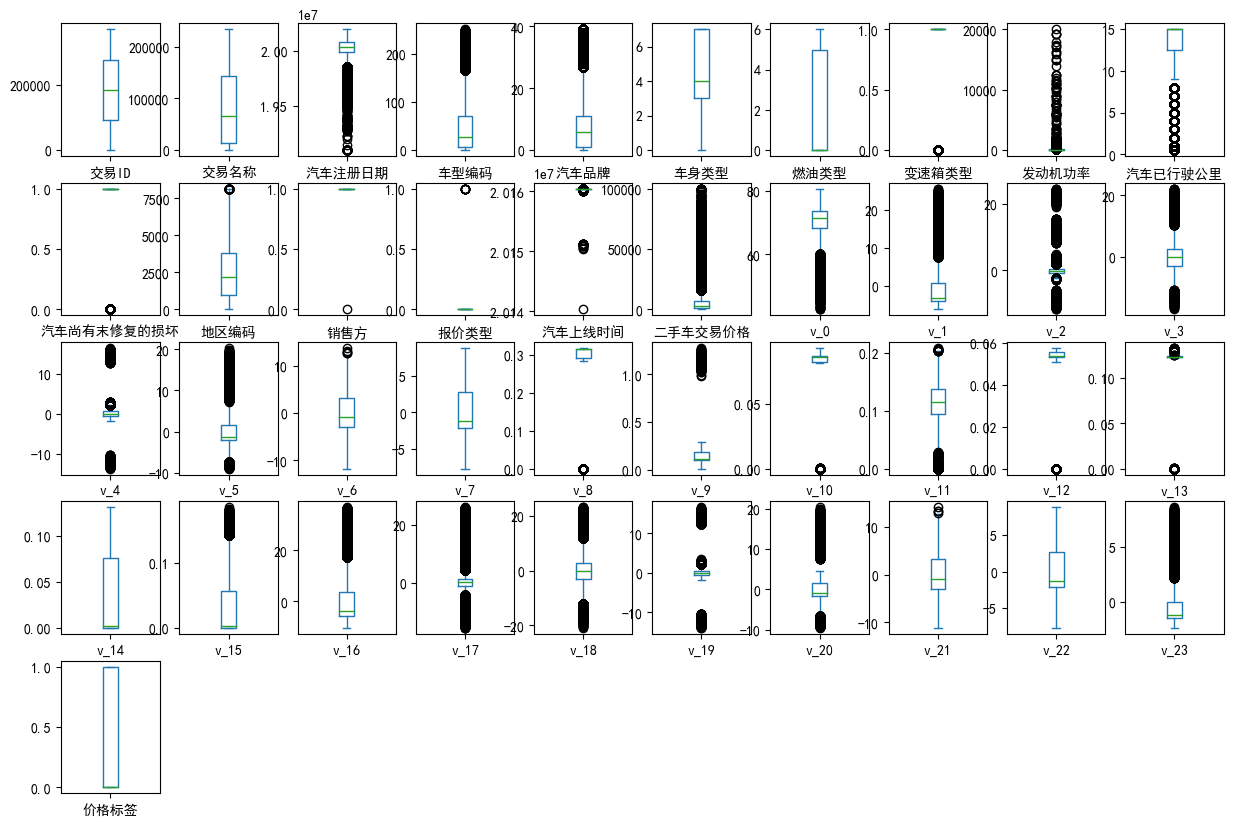

In [20]:
a=df_train.plot.box(subplots=True, layout=(5, 10), figsize=(15, 10))

In [5]:
df_train['价格标签']= pd.cut(df_train.二手车交易价格,\
                             bins=[0, df_train.二手车交易价格.mean(), df_train.二手车交易价格.max()+1],
                                   labels=[0,1])

In [6]:
df_train[['二手车交易价格','价格标签']]

,二手车交易价格,价格标签
0,520,0
1,5500,0
2,1100,0
3,1200,0
4,3300,0
...,...,...
249995,1200,0
249996,1200,0
249997,16500,1
249998,31950,1


In [7]:
df_test.to_csv('../data/car_testA_0110.csv', index=False)
df_train.to_csv('../data/car_train_0110.csv', index=False)

<Axes: title={'center': '二手车交易价格箱型图'}>

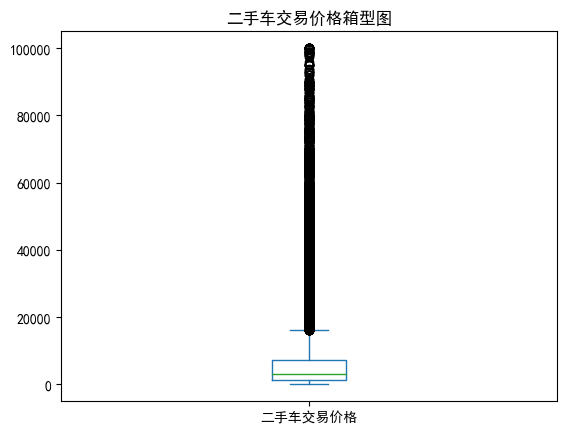

<Axes: ylabel='Frequency'>

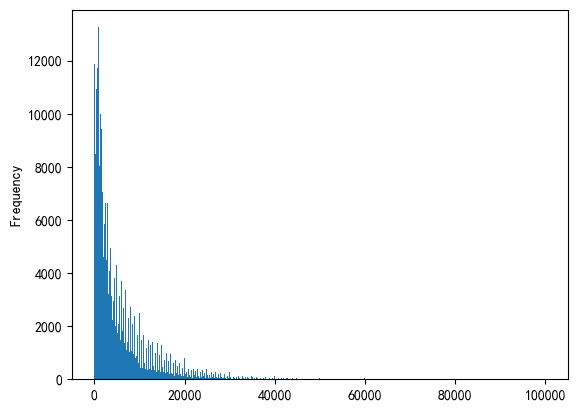

In [8]:
df_train.二手车交易价格.plot.box(title='二手车交易价格箱型图')
plt.show()
df_train.二手车交易价格.plot.hist(bins=500)

<Axes: ylabel='count'>

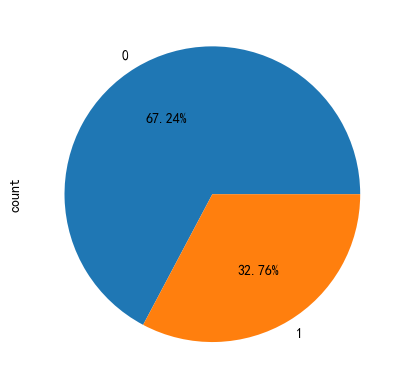

In [12]:
df_train.价格标签.value_counts().plot.pie(autopct='%.2f%%')

<Axes: ylabel='Frequency'>

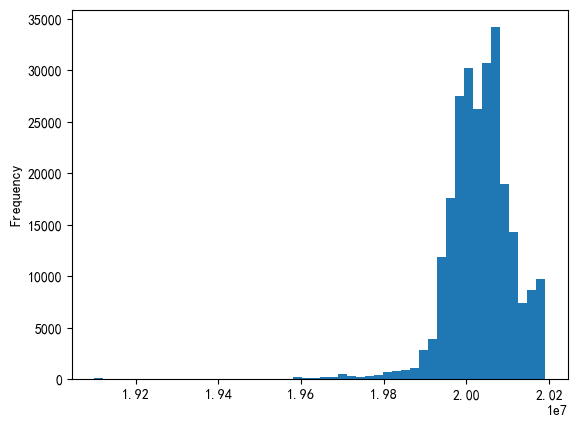

In [13]:
df_train.汽车注册日期.plot.hist(bins=50)

<Axes: xlabel='汽车注册日期', ylabel='Count'>

<Axes: xlabel='汽车注册日期', ylabel='Count'>

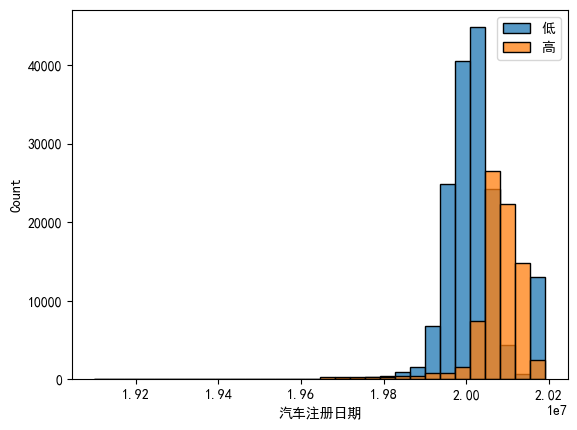

In [21]:
sns.histplot(df_train[df_train.价格标签==0],x='汽车注册日期',label='低',bins=30)
sns.histplot(df_train[df_train.价格标签==1],x='汽车注册日期',label='高',bins=30)
plt.legend()

<Axes: xlabel='汽车注册日期', ylabel='Density'>

<Axes: xlabel='汽车注册日期', ylabel='Density'>

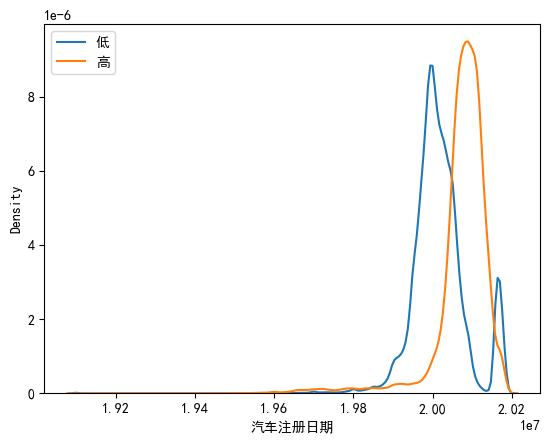

In [22]:
sns.kdeplot(df_train[df_train.价格标签==0],x='汽车注册日期',label='低')
sns.kdeplot(df_train[df_train.价格标签==1],x='汽车注册日期',label='高')
plt.legend()